In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report, accuracy_score
from scipy.optimize import curve_fit
from datetime import timedelta

In [3]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [15]:
# Loading the data
llama_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_llama_labeled.csv'))
comments_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_for_analysis.csv'))
df = pd.merge(
    comments_df, 
    llama_df[['comment_id', 'category', 'sentiment', 'confidence']], 
    on='comment_id', 
    how='inner')
df['comment_date'] = pd.to_datetime(df['comment_date'])
df.head()

,comment_id,parent_id,parent_text,text_preprocessed,video_title,video_context,video_id,comment_date,author_hash,days_from_genai_announcement,...,mentions_genai,mentions_business_model,mentions_game,likes,like_count_log,is_spike,z_score,category,sentiment,confidence
0,UgzLPJdZudI_r4we6c94AaABAg,NaN,NaN,Good choice of music,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:58:59,a866cdf8b46bef61d38e39e66a5beed117447786cc3a65...,-887,...,False,False,False,13,2.639057,False,NaN,Game_Related,Pos,0.90
1,UgyAUoHvzWPWW5jVv994AaABAg,NaN,NaN,this looks VERY fun,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:18,5f3f2b5524e8a6c69e3d960a00e26fb58fd4e70c490b16...,-887,...,False,False,False,782,6.663133,False,NaN,Game_Related,Pos,0.95
2,UgzwutSd2BKZ6h-6dRF4AaABAg,NaN,NaN,these graphics are sick!,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:37,93edc8fe622d6884c56b40ed55a8df4d8233ba69c46f71...,-887,...,False,False,True,3,1.386294,False,NaN,Game_Related,Pos,0.95
3,UgzlrEdJ-IeAuox6BLJ4AaABAg,NaN,NaN,"Ok, Arc Raiders....I see you",Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:48,9451ccfd3f4589dd62a33ec55593cc4694d5f1d924008a...,-887,...,False,False,True,6,1.945910,False,NaN,Game_Related,Neu,0.80
4,UgwcSGsGzi8y4_ynAhh4AaABAg,NaN,NaN,came here to shazam the song. The trailer is p...,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:58,8a4e74825f2dde5179ec5faf2f63728a4b3335f29919ff...,-887,...,False,False,True,3,1.386294,False,NaN,Others,Pos,0.80


In [16]:
# =============================================================================
# 1. MATHEMATICAL FUNCTIONS
# =============================================================================

def decay_function(t, s0, lam):
    """Standard exponential decay formula: S(t) = s0 * e^(-lambda * t)"""
    return s0 * np.exp(-lam * t)

def fit_exponential_decay(daily_df, label="Group"):
    """
    Identifies the peak, fits the decay curve for the following 60 days,
    and calculates the Half-Life.
    """
    # 1. Identify peak volume date
    peak_idx = daily_df['volume'].idxmax()
    peak_date = daily_df.loc[peak_idx, 'comment_date']
    
    # 2. Filter for 60 days post-peak
    df_fit = daily_df[daily_df['comment_date'] >= peak_date].head(60).copy()
    df_fit['days'] = (df_fit['comment_date'] - peak_date).dt.days
    
    x_data = df_fit['days'].values
    y_data = df_fit['volume'].values
    
    try:
        # Initial guess: s0 = peak volume, lambda = 0.1
        popt, _ = curve_fit(decay_function, x_data, y_data, p0=[y_data[0], 0.1])
        s0_fit, lam_fit = popt
        half_life = np.log(2) / lam_fit
        
        # Prepare fit line for plotting
        fit_dates = [peak_date + timedelta(days=int(d)) for d in x_data]
        fit_values = decay_function(x_data, *popt)
        
        return {
            'peak_date': peak_date,
            'half_life': half_life,
            'decay_constant': lam_fit,
            'fit_dates': fit_dates,
            'fit_values': fit_values
        }
    except Exception as e:
        print(f"Could not fit decay for {label}: {e}")
        return None

In [17]:
# =============================================================================
# 2. DATA PROCESSING
# =============================================================================

# Map sentiment to numeric scores for weighting
sentiment_map = {'Pos': 1, 'Neu': 0, 'Neg': -1}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# Define Research Groups
# Group A: General Game Discourse
game_cats = ['Game_Related', 'AI_Voice_Related', 'Business_Model_Related']
df_game = df[df['category'].isin(game_cats)].copy()

# Group B: Isolated AI Voice Controversy
df_ai = df[df['category'] == 'AI_Voice_Related'].copy()

# Aggregate Daily Volume and Mean Sentiment
def get_daily_stats(df_subset):
    return df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume=('comment_id', 'count'),
        sentiment=('sentiment_score', 'mean')
    ).reset_index().rename(columns={'index': 'comment_date'})

daily_game = get_daily_stats(df_game)
daily_ai = get_daily_stats(df_ai)

# Ensure date column is datetime for plotting
daily_game['comment_date'] = pd.to_datetime(daily_game['comment_date'])
daily_ai['comment_date'] = pd.to_datetime(daily_ai['comment_date'])

# Run Mathematical Fits
game_results = fit_exponential_decay(daily_game, "General Game")
ai_results = fit_exponential_decay(daily_ai, "AI Controversy")

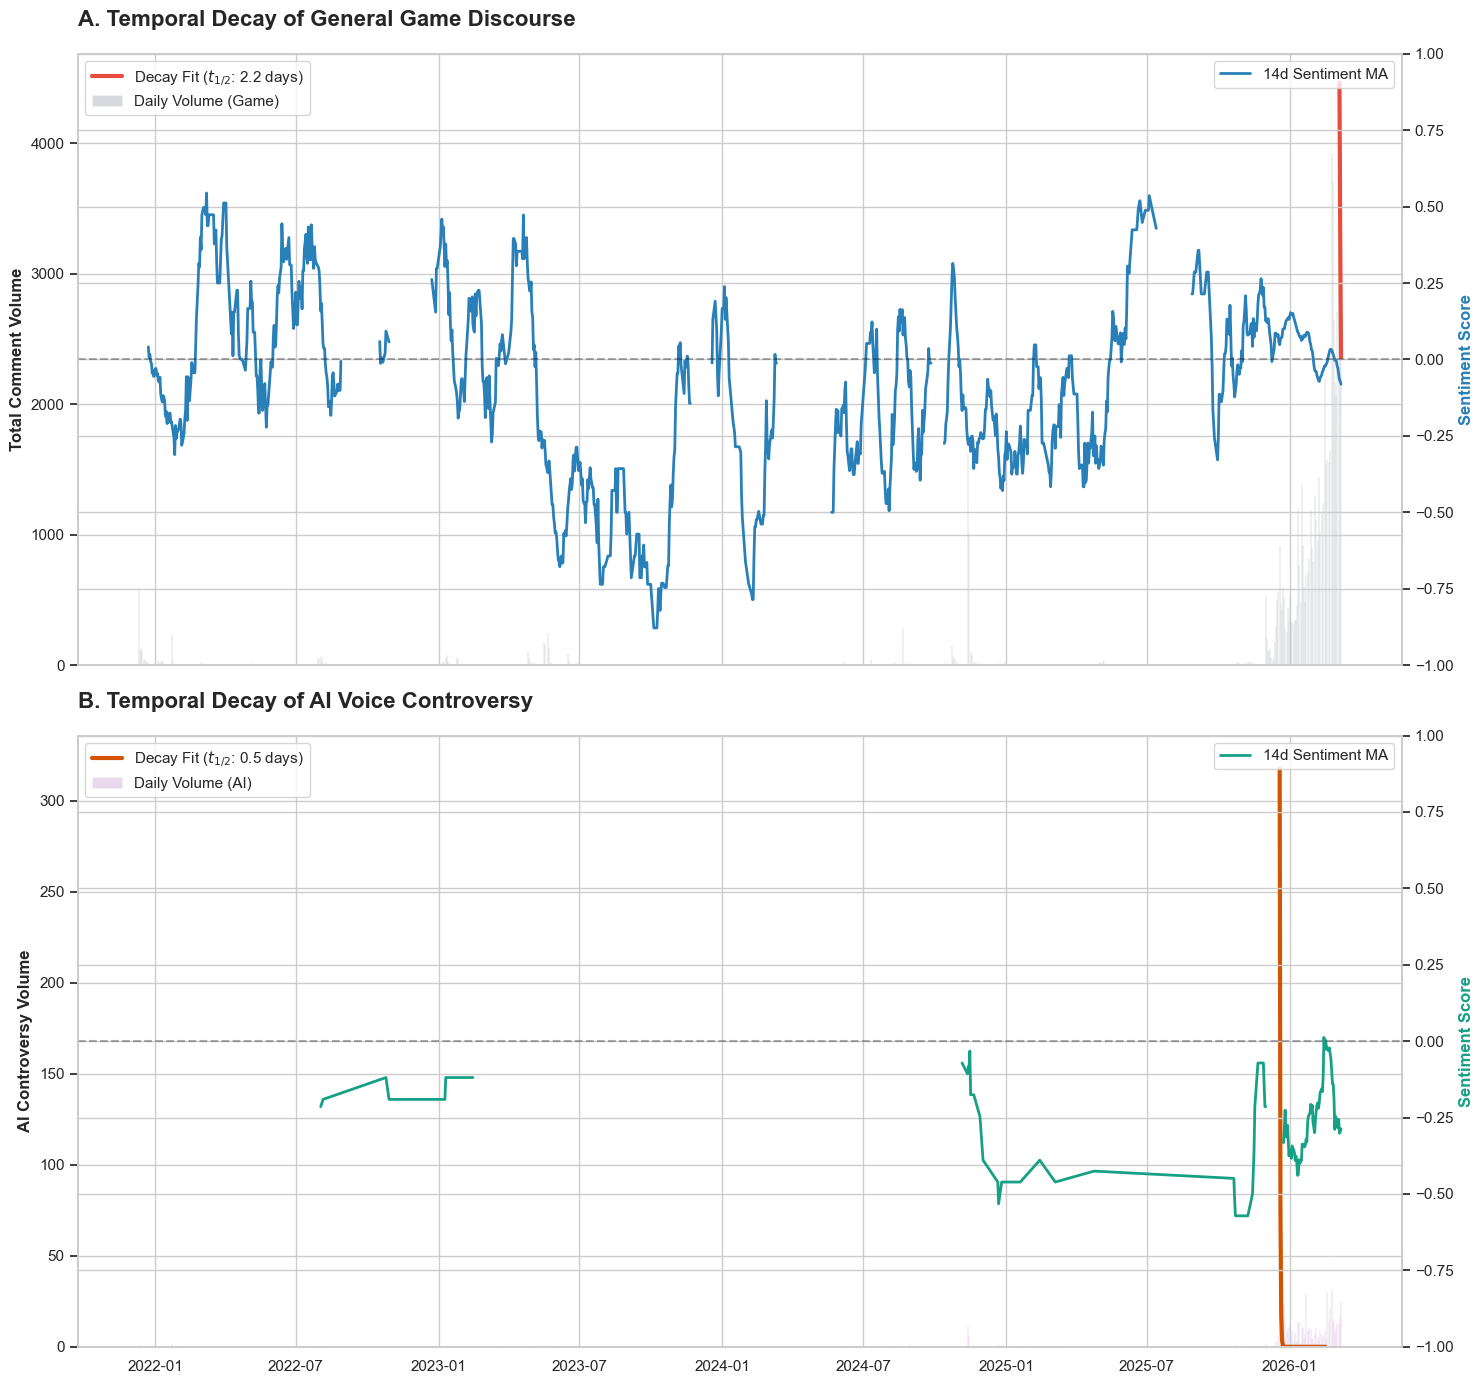

FINAL ANALYSIS RESULTS
GAME DISCOURSE  | Peak: 2026-03-06 | Half-Life: 2.17 days
AI CONTROVERSY  | Peak: 2025-12-19 | Half-Life: 0.48 days


In [ ]:
# =============================================================================
# 3. VISUALIZATION
# =============================================================================

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)

# --- PLOT 1: GENERAL GAME DISCOURSE ---
# Volume Bars
ax1.bar(daily_game['comment_date'], daily_game['volume'], color='#34495E', alpha=0.2, label='Daily Volume (Game)')
# Decay Fit Line
if game_results:
    ax1.plot(game_results['fit_dates'], game_results['fit_values'], color='#E74C3C', linewidth=3, 
             label=f"Decay Fit ($t_{{1/2}}$: {game_results['half_life']:.1f} days)")
# Sentiment Secondary Axis
ax1_s = ax1.twinx()
ax1_s.plot(daily_game['comment_date'], daily_game['sentiment'].rolling(14).mean(), color='#2980B9', linewidth=2, label='14d Sentiment MA')
ax1_s.axhline(0, color='black', linestyle='--', alpha=0.3)
ax1_s.set_ylim(-1, 1)

# Formatting
ax1.set_title("A. Temporal Decay of General Game Discourse", loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel("Total Comment Volume", fontsize=12, fontweight='bold')
ax1_s.set_ylabel("Sentiment Score", color='#2980B9', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1_s.legend(loc='upper right', frameon=True)

# --- PLOT 2: AI VOICE CONTROVERSY ---
# Volume Bars
ax2.bar(daily_ai['comment_date'], daily_ai['volume'], color='#8E44AD', alpha=0.2, label='Daily Volume (AI)')
# Decay Fit Line
if ai_results:
    ax2.plot(ai_results['fit_dates'], ai_results['fit_values'], color='#D35400', linewidth=3, 
             label=f"Decay Fit ($t_{{1/2}}$: {ai_results['half_life']:.1f} days)")
# Sentiment Secondary Axis
ax2_s = ax2.twinx()
ax2_s.plot(daily_ai['comment_date'], daily_ai['sentiment'].rolling(14).mean(), color='#16A085', linewidth=2, label='14d Sentiment MA')
ax2_s.axhline(0, color='black', linestyle='--', alpha=0.3)
ax2_s.set_ylim(-1, 1)

# Formatting
ax2.set_title("B. Temporal Decay of AI Voice Controversy", loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel("AI Controversy Volume", fontsize=12, fontweight='bold')
ax2_s.set_ylabel("Sentiment Score", color='#16A085', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', frameon=True)
ax2_s.legend(loc='upper right', frameon=True)

# Global Cleanup
plt.xlabel("Timeline (2024 - 2026)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ArcRaiders_Sentiment_HalfLife_Analysis.png'), dpi=400, bbox_inches='tight')
plt.show()

# Print Statistics for Paper Results Section
print(f"{'='*50}")
print(f"FINAL ANALYSIS RESULTS")
print(f"{'='*50}")
if game_results:
    print(f"GAME DISCOURSE  | Peak: {game_results['peak_date'].date()} | Half-Life: {game_results['half_life']:.2f} days")
if ai_results:
    print(f"AI CONTROVERSY  | Peak: {ai_results['peak_date'].date()} | Half-Life: {ai_results['half_life']:.2f} days")
print(f"{'='*50}")

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Weighted Sentiment Calculation
# We calculate the Weighted Score = sentiment_score * (1 + like_count_log)
# To get the daily average, we use: Sum(Weighted Scores) / Sum(Weights)
df['weighted_sentiment'] = df['sentiment_score'] * (df['like_count_log'] + 1)
df['weight_factor'] = df['like_count_log'] + 1

def get_weighted_daily_stats(df_subset):
    daily = df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume=('comment_id', 'count'),
        sum_weighted_sentiment=('weighted_sentiment', 'sum'),
        sum_weights=('weight_factor', 'sum')
    ).reset_index().rename(columns={'index': 'comment_date'})
    
    # Calculate the Weighted Mean Sentiment
    daily['weighted_mean_sentiment'] = daily['sum_weighted_sentiment'] / daily['sum_weights']
    # 7-day rolling average for smoothness
    daily['sentiment_ma'] = daily['weighted_mean_sentiment'].rolling(window=7, min_periods=1).mean()
    return daily

# Process Groups
daily_game = get_weighted_daily_stats(df[df['category'].isin(['Game_Related', 'AI_Voice_Related', 'Business_Model_Related'])])
daily_ai = get_weighted_daily_stats(df[df['category'] == 'AI_Voice_Related'])

# 2. Build Interactive Plotly Figure
fig = make_subplots(rows=2, cols=1, 
                    shared_xaxes=True, 
                    vertical_spacing=0.1,
                    subplot_titles=("A. General Game Discourse (Weighted)", "B. AI Voice Controversy (Weighted)"),
                    specs=[[{"secondary_y": True}], [{"secondary_y": True}]])

# --- SUBPLOT 1: GAME ---
# Volume Bars (Higher Opacity/Less Transparency)
fig.add_trace(go.Bar(x=daily_game['comment_date'], y=daily_game['volume'], 
                     name="Game Volume", marker_color='rgba(44, 62, 80, 0.9)'), # Alpha
              row=1, col=1, secondary_y=False)

# Weighted Sentiment Line
fig.add_trace(go.Scatter(x=daily_game['comment_date'], y=daily_game['sentiment_ma'], 
                         name="Weighted Sentiment (MA)", line=dict(color='#2980B9', width=3)),
              row=1, col=1, secondary_y=True)

# --- SUBPLOT 2: AI VOICE ---
# Volume Bars (Higher Opacity)
fig.add_trace(go.Bar(x=daily_ai['comment_date'], y=daily_ai['volume'], 
                     name="AI Controversy Volume", marker_color='rgba(142, 68, 173, 0.6)'),
              row=2, col=1, secondary_y=False)

# Weighted Sentiment Line
fig.add_trace(go.Scatter(x=daily_ai['comment_date'], y=daily_ai['sentiment_ma'], 
                         name="AI Weighted Sentiment (MA)", line=dict(color='#16A085', width=3)),
              row=2, col=1, secondary_y=True)

# 3. Interactivity & Styling
fig.update_layout(
    height=900,
    title_text="Arc Raiders: Multi-Aspect Sentiment Half-Life Analysis",
    showlegend=True,
    xaxis2_title="Timeline (Click & Drag to Zoom)",
    # Add Range Selector (Buttons for 1m, 6m, etc.)
    xaxis_rangeslider_visible=False,
    xaxis_rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(step="all")
        ])
    )
)

# Set Y-axis constraints for sentiment
fig.update_yaxes(title_text="Volume", secondary_y=False)
fig.update_yaxes(title_text="Weighted Sentiment", range=[-1.1, 1.1], secondary_y=True)

fig.show()

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160500 entries, 0 to 160499
Data columns (total 27 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   comment_id                       160500 non-null  str           
 1   parent_id                        34930 non-null   str           
 2   parent_text                      34929 non-null   str           
 3   text_preprocessed                160500 non-null  str           
 4   video_title                      160500 non-null  str           
 5   video_context                    151296 non-null  str           
 6   video_id                         160500 non-null  str           
 7   comment_date                     160500 non-null  datetime64[us]
 8   author_hash                      160500 non-null  str           
 9   days_from_genai_announcement     160500 non-null  int64         
 10  days_from_business_model_change  160500 non-null  int64